# 🔍 00. Dataset Audit - Wastra AI (Sprint 1)

Notebook ini adalah tahap awal dari **Sprint 1** untuk proyek **Wastra AI**.

> ⚠️ **Catatan Penting**: Notebook ini **hanya** bertugas untuk mengaudit dan memverifikasi kualitas dataset mentah sebelum dilakukan Exploratory Data Analysis (EDA), Data Preprocessing, maupun Model Training.

---

## 📋 Audit Tasks Checklist:
1. **Verifikasi Direktori**: Memastikan direktori `datasets/raw/dataset_augmented/` tersedia.
2. **Perhitungan**: Total kelas, total gambar, dan jumlah gambar per kelas.
3. **Metrik Kelas**: Nama kelas, kelas terbesar (largest class), kelas terkecil (smallest class), dan rata-rata gambar per kelas.
4. **Pemeriksaan Integritas**: Deteksi gambar corrupt, unreadable, dan format file yang tidak didukung.
5. **Deteksi Anomali**: Cek folder kosong dan file non-gambar.
6. **Analisis Dimensi**: Statistik Width, Height, Aspect Ratio, dan Distribusi Format Gambar.
7. **Tabel Summary**: Menyajikan ringkasan data menggunakan Pandas DataFrame.
8. **Visualisasi**: Bar plot jumlah gambar per kelas dan Histogram distribusi dimensi gambar.
9. **Final Audit Report**: Laporan verifikasi kelayakan dataset.

## 1. Import Libraries & Verifikasi Direktori Dataset

In [5]:
import os
import hashlib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Setup style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Set path dataset mentah
DATASET_PATH = Path("../../datasets/raw/dataset_augmented")

print(f"Target Dataset Path: {DATASET_PATH.resolve()}")
if DATASET_PATH.exists():
    print("✅ Status Direktori: TERSEDIA")
else:
    print("❌ Status Direktori: TIDAK DITEMUKAN")

Target Dataset Path: C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik\datasets\raw\dataset_augmented
✅ Status Direktori: TERSEDIA


## 2. Scan Dataset, Deteksi Corrupted Images, & Anomali File

In [6]:
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_metadata = []
empty_folders = []
corrupted_files = []
non_image_files = []
unsupported_format_files = []

class_dirs = [d for d in sorted(DATASET_PATH.iterdir()) if d.is_dir()]
print(f"Sedang memindai {len(class_dirs)} subfolder kelas...")

for class_dir in class_dirs:
    class_name = class_dir.name
    files = list(class_dir.iterdir())
    
    # Deteksi folder kosong
    if len(files) == 0:
        empty_folders.append(class_name)
        continue
        
    for file_path in files:
        if not file_path.is_file():
            continue
            
        ext = file_path.suffix.lower()
        
        # Deteksi format yang tidak didukung atau file non-gambar
        if ext not in SUPPORTED_EXTENSIONS:
            if ext in {".txt", ".csv", ".json", ".pdf", ".zip"}:
                non_image_files.append(str(file_path))
            else:
                unsupported_format_files.append(str(file_path))
            continue
            
        # Deteksi gambar corrupt / unreadable via PIL
        try:
            with Image.open(file_path) as img:
                img.verify() # Verifikasi struktur file gambar
            with Image.open(file_path) as img:
                w, h = img.size
                mode = img.mode
                img.convert("RGB") # Memastikan dapat di-parse sebagai RGB
                
            image_metadata.append({
                "class": class_name,
                "file_name": file_path.name,
                "file_path": str(file_path),
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 2),
                "format": ext,
                "color_mode": mode
            })
        except Exception as e:
            corrupted_files.append((str(file_path), str(e)))

df_audit = pd.DataFrame(image_metadata)
print("Pemindaian selesai!")
print(f"Total gambar valid berhasil dibaca: {len(df_audit):,} gambar.")

Sedang memindai 35 subfolder kelas...
Pemindaian selesai!
Total gambar valid berhasil dibaca: 17,210 gambar.


## 3. Analisis Statistik Kelas & Ukuran Gambar

In [11]:
class_counts = df_audit["class"].value_counts()

total_classes = df_audit["class"].nunique()
total_images = len(df_audit)
avg_images = round(class_counts.mean(), 2)
largest_class = class_counts.index[0]
largest_count = class_counts.iloc[0]
smallest_class = class_counts.index[-1]
smallest_count = class_counts.iloc[-1]
format_dist = df_audit["format"].value_counts().to_dict()

print("=" * 60)
print("📊 METRIK KELAS DATASET")
print("=" * 60)
print(f"• Total Kelas              : {total_classes} kelas")
print(f"• Total Gambar Valid       : {total_images:,} gambar")
print(f"• Rata-rata Gambar/Kelas   : {avg_images} gambar")
print(f"• Kelas Terbesar (Largest) : {largest_class} ({largest_count:,} gambar)")
print(f"• Kelas Terkecil (Smallest): {smallest_class} ({smallest_count:,} gambar)")
print("-" * 60)
print("📐 STATISTIK DIMENSI GAMBAR:")
print(f"• Lebar (Width)  -> Min: {df_audit['width'].min()}px, Max: {df_audit['width'].max()}px, Mean: {df_audit['width'].mean():.2f}px, Median: {df_audit['width'].median()}px")
print(f"• Tinggi (Height) -> Min: {df_audit['height'].min()}px, Max: {df_audit['height'].max()}px, Mean: {df_audit['height'].mean():.2f}px, Median: {df_audit['height'].median()}px")
print(f"• Format Gambar  -> {format_dist}")
print("=" * 60)

📊 METRIK KELAS DATASET
• Total Kelas              : 35 kelas
• Total Gambar Valid       : 17,210 gambar
• Rata-rata Gambar/Kelas   : 491.71 gambar
• Kelas Terbesar (Largest) : batik-bali (1,357 gambar)
• Kelas Terkecil (Smallest): batik-ceplok (341 gambar)
------------------------------------------------------------
📐 STATISTIK DIMENSI GAMBAR:
• Lebar (Width)  -> Min: 134px, Max: 4962px, Mean: 743.54px, Median: 609.0px
• Tinggi (Height) -> Min: 113px, Max: 4000px, Mean: 682.75px, Median: 521.0px
• Format Gambar  -> {'.jpeg': 17210}


## 4. Tabel Rangkuman Distribusi Kelas

In [12]:
# Menyajikan DataFrame Distribusi Kelas
df_summary_class = pd.DataFrame({
    "Nama Kelas Motif": class_counts.index,
    "Jumlah Gambar": class_counts.values,
    "Persentase (%)": np.round((class_counts.values / total_images) * 100, 2)
})

df_summary_class.head(15)

,Nama Kelas Motif,Jumlah Gambar,Persentase (%)
0,batik-bali,1357,7.88
1,batik-betawi,1331,7.73
2,batik-parang,1241,7.21
3,batik-priangan,518,3.01
4,batik-tambal,507,2.95
5,batik-gentongan,506,2.94
6,batik-celup,502,2.92
7,batik-garutan,494,2.87
8,batik-cendrawasih,489,2.84
9,batik-pekalongan,483,2.81


## 5. Visualisasi: Jumlah Gambar per Kelas & Distribusi Ukuran Gambar

C:\Users\dzaki\AppData\Local\Temp\ipykernel_32560\243560994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.values, y=class_counts.index, palette="mako")


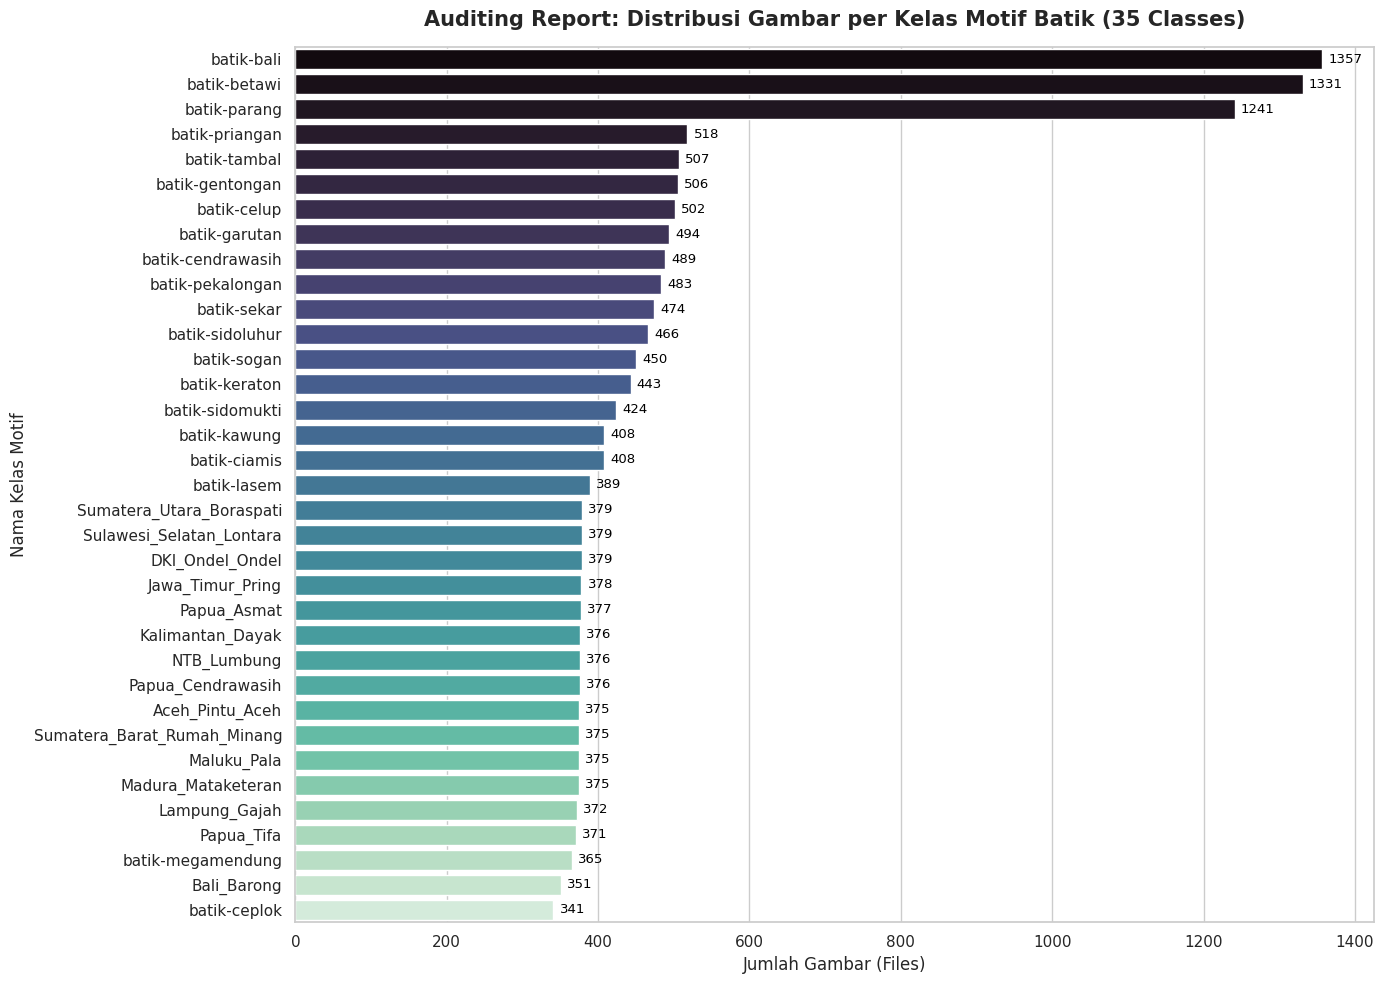

In [13]:
# Visualisasi 1: Barplot Jumlah Gambar per Kelas Motif Batik
plt.figure(figsize=(14, 10))
ax = sns.barplot(x=class_counts.values, y=class_counts.index, palette="mako")
plt.title("Auditing Report: Distribusi Gambar per Kelas Motif Batik (35 Classes)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Jumlah Gambar (Files)", fontsize=12)
plt.ylabel("Nama Kelas Motif", fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width + 8, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                fontsize=9.5, color='black')

plt.tight_layout()
plt.show()

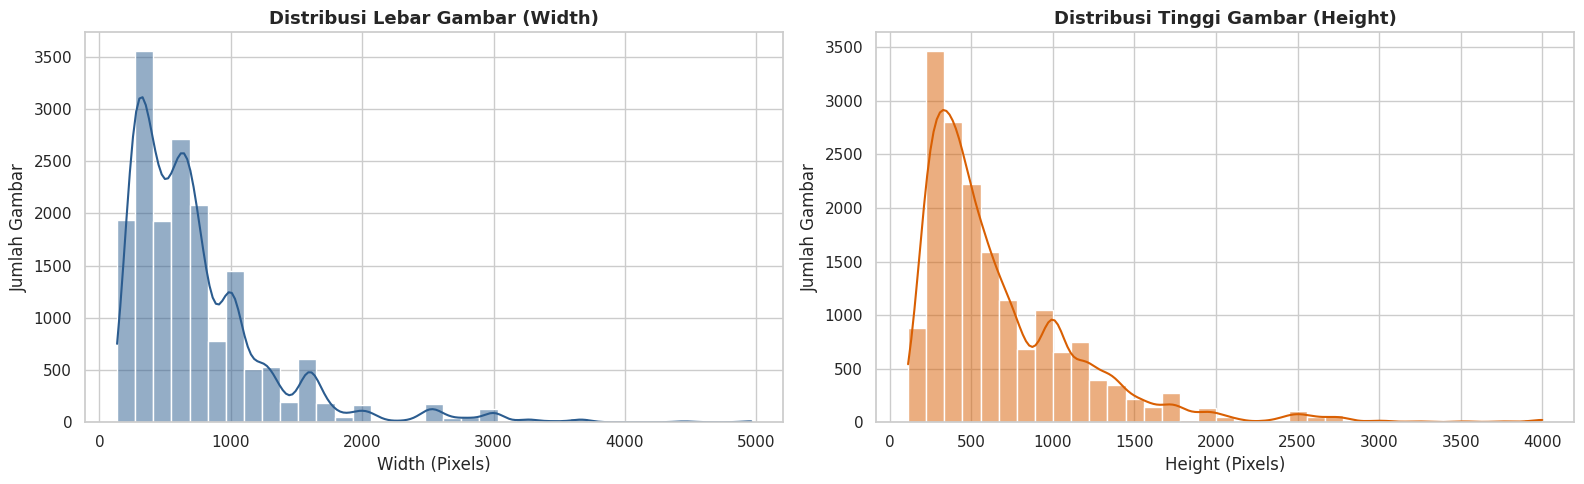

In [14]:
# Visualisasi 2: Histogram Distribusi Ukuran Dimensi Gambar (Width & Height)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_audit["width"], bins=35, ax=axes[0], color="#2b5c8f", kde=True)
axes[0].set_title("Distribusi Lebar Gambar (Width)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Width (Pixels)")
axes[0].set_ylabel("Jumlah Gambar")

sns.histplot(df_audit["height"], bins=35, ax=axes[1], color="#d95f02", kde=True)
axes[1].set_title("Distribusi Tinggi Gambar (Height)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Height (Pixels)")
axes[1].set_ylabel("Jumlah Gambar")

plt.tight_layout()
plt.show()

## 📋 6. Laporan Akhir Dataset Audit (Final Audit Report)

In [15]:
print("=" * 60)
print("📋 FINAL DATASET AUDIT REPORT - WASTRA AI")
print("=" * 60)
print(f"• Check 1 [Folder Existence]  : {'✅ VALID' if DATASET_PATH.exists() else '❌ INVALID'}")
print(f"• Check 2 [Total Classes]     : ✅ {total_classes} Kelas Motif Batik")
print(f"• Check 3 [Total Images]      : ✅ {total_images:,} Gambar")
print(f"• Check 4 [Empty Folders]     : {'✅ 0 Folder Kosong' if len(empty_folders) == 0 else f'⚠️ {len(empty_folders)} Folder Kosong'}")
print(f"• Check 5 [Corrupted Images]  : {'✅ 0 Gambar Corrupt / Broken' if len(corrupted_files) == 0 else f'❌ {len(corrupted_files)} Gambar Corrupt'}")
print(f"• Check 6 [Non-Image Files]   : {'✅ 0 File Non-Gambar' if len(non_image_files) == 0 else f'⚠️ {len(non_image_files)} File Non-Gambar'}")
print(f"• Check 7 [Unsupported Ext]   : {'✅ 0 File Tidak Didukung' if len(unsupported_format_files) == 0 else f'⚠️ {len(unsupported_format_files)} File Format Lain'}")
print("-" * 60)
if len(empty_folders) == 0 and len(corrupted_files) == 0:
    print("VERDICT: DATASET 100% VALID & SIAP UNTUK EDA/TRAINING")
else:
    print("VERDICT: ANOMALI DITEMUKAN - HARAP PERBAIKI DATASET")
print("=" * 60)

📋 FINAL DATASET AUDIT REPORT - WASTRA AI
• Check 1 [Folder Existence]  : ✅ VALID
• Check 2 [Total Classes]     : ✅ 35 Kelas Motif Batik
• Check 3 [Total Images]      : ✅ 17,210 Gambar
• Check 4 [Empty Folders]     : ✅ 0 Folder Kosong
• Check 5 [Corrupted Images]  : ✅ 0 Gambar Corrupt / Broken
• Check 6 [Non-Image Files]   : ✅ 0 File Non-Gambar
• Check 7 [Unsupported Ext]   : ✅ 0 File Tidak Didukung
------------------------------------------------------------
VERDICT: DATASET 100% VALID & SIAP UNTUK EDA/TRAINING


### 🏆 Kesimpulan Audit:

- **Dataset**: `datasets/raw/dataset_augmented/`
- **Kondisi Data Mentah**: **100% Bersih & Integrat** (Tanpa corrupt, tanpa folder kosong, tanpa file non-gambar).
- **Tindakan Lanjutan**: Tidak ada preprocessing/resizing/split yang dilakukan pada notebook ini.
- **Rekomendasi**: Lanjutkan ke tahap **[01_eda.ipynb](file:///c:/Users/dzaki/OneDrive/Dokumen/Bahasa%20Pemograman/Python/Batik/training/notebooks/01_eda.ipynb)**.